<a href="https://colab.research.google.com/github/MiltonPC-Fisica/Exp-Cuanticos-I-Grupo-4-/blob/main/C%C3%B3digo_del_trabajo_Espectroscop%C3%ADa_UV_Vis_del_I2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install uncertainties
!pip install adjustText

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.1 MB/s eta 0:00:00


In [2]:
from scipy.fft import fft, fftfreq
import pandas as pd
from scipy.odr import ODR, Model, RealData
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize
from scipy.signal import butter, sosfilt, filtfilt, find_peaks
import uncertainties as unc
from uncertainties import unumpy as unp
from matplotlib.font_manager import FontProperties
from adjustText import adjust_text

In [3]:
data = pd.read_csv("ALTA RES.txt", sep='\t', decimal=',')
data['Absorbancia'] = -np.log10(data['T(lambda)']/100)

In [4]:
y = data['Absorbancia']
x = data['lambda']

In [5]:
h = 4.136*10**(-15) #eV s
hbar = h/(2*np.pi)
c = 2.998*10**8 #m/s

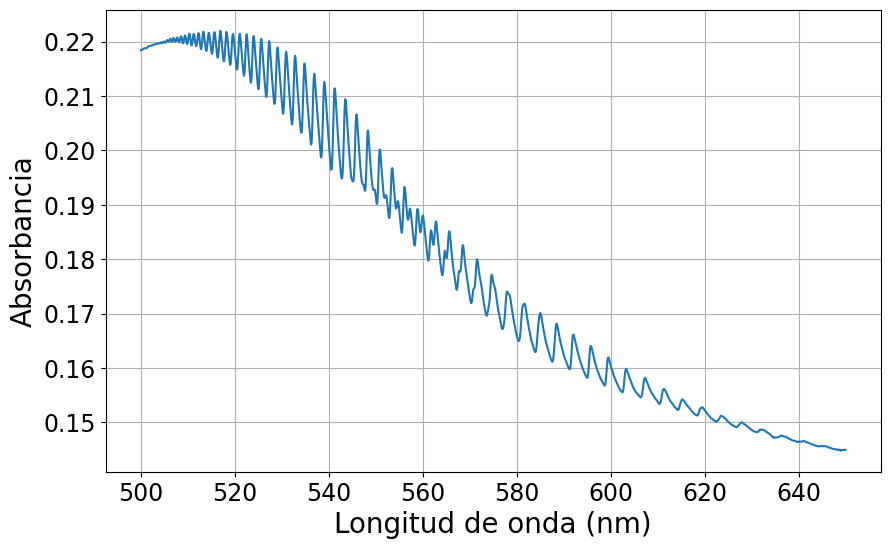

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlabel('Longitud de onda (nm)', size=20)
plt.ylabel('Absorbancia', size=20)
plt.grid()
plt.show()

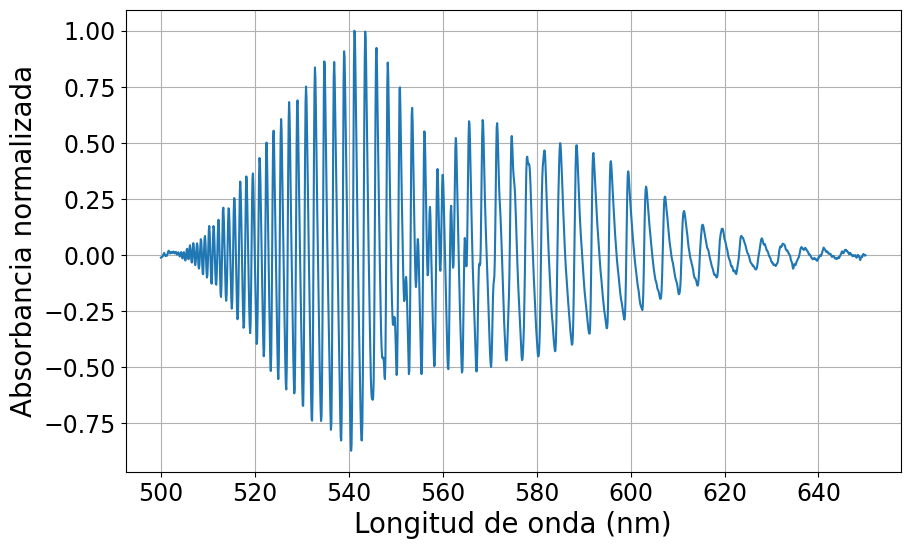

In [8]:
filtered = filtfilt(*butter(2, 0.1, 'hp',fs=10), y) # w = 2f_c/f_s
#La frec de corte entonces es de f_c=0.5? i.e la long de onda de corte es de lamda_c=5nm?
filtnorm= filtered/np.max(filtered)
plt.figure(figsize=(10, 6))
plt.plot(x, filtnorm)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlabel('Longitud de onda (nm)', size=20)
plt.ylabel('Absorbancia normalizada', size=20)
plt.grid()
plt.savefig('FiltroI2.pdf',dpi=300)
plt.show()

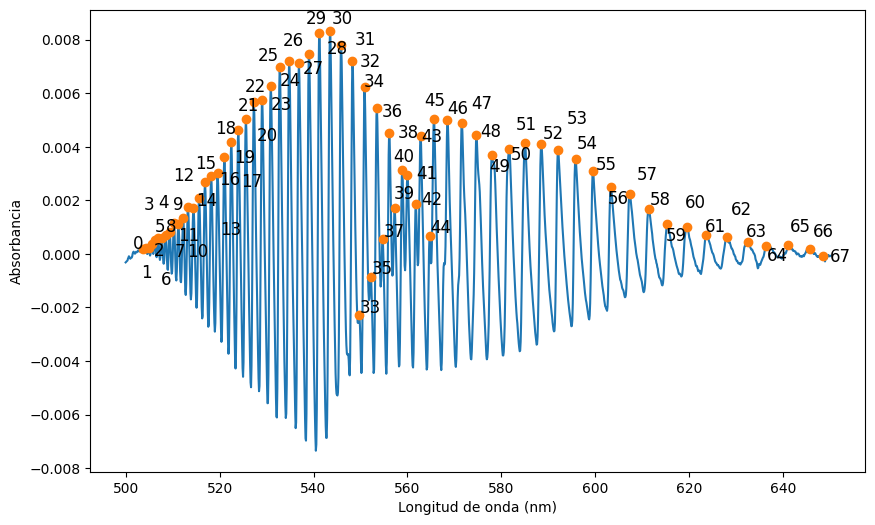

In [ ]:
def sos(w):
  return butter(2, w, 'hp')

x = data['lambda']
filtered = filtfilt(*sos(0.01), y)
x_picos, _ = find_peaks(filtered, prominence=0.0001)

plt.figure(figsize=(10, 6))
plt.plot(x, filtered)
plt.errorbar(x[x_picos], filtered[x_picos], fmt='o', label ='Picos')
texts = []
for i in range(len(x_picos)):
  texts.append(plt.text(x[x_picos[i]], filtered[x_picos[i]], i, fontsize=12))
adjust_text(texts)
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Absorbancia')
plt.show()

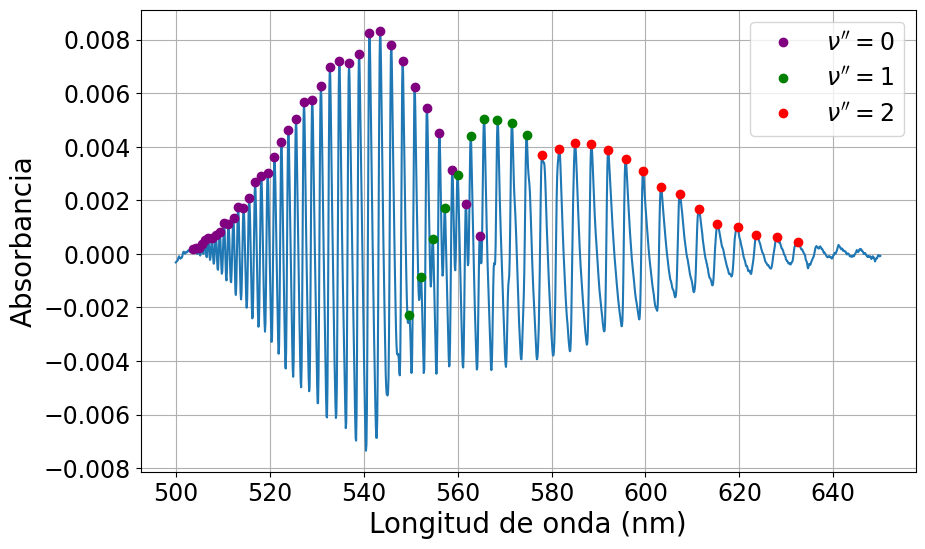

In [ ]:
indices0 = x_picos
arr_del = []

for i in range(len(x_picos)):
  if i > 44:
    arr_del.append(i)

a2 = (33, 35, 37, 39, 41, 43)
for i in a2:
  arr_del.append(i)

indices0 = np.delete(indices0, arr_del)
serie0= []
for i in indices0:
  serie0.append(x[i])

indices1 = []

for i in a2:
  indices1.append(x_picos[i])

for i in range(len(x_picos)):
  if 44 < i < 49:
    indices1.append(x_picos[i])

serie1 = []
for i in indices1:
  serie1.append(x[i])

indices2 = []

for i in range(len(x_picos[:-4])):
  if i > 48:
    indices2.append(x_picos[i])

serie2 = []
for i in indices2:
  serie2.append(x[i])

serie0_unc = unp.uarray(serie0, np.full(len(serie0), 0.1))
serie1_unc = unp.uarray(serie1, np.full(len(serie1), 0.1))
serie2_unc = unp.uarray(serie2, np.full(len(serie2), 0.1))

plt.figure(figsize=(10, 6))
plt.plot(x, filtered)
plt.errorbar(serie0, filtered[indices0], fmt='o', color='purple', label =r'$\nu^{\prime \prime}=0$')
plt.errorbar(serie1, filtered[indices1], fmt='go', label =r'$\nu^{\prime \prime}=1$')
plt.errorbar(serie2, filtered[indices2], fmt='ro', label =r'$\nu^{\prime \prime}=2$')
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlabel('Longitud de onda (nm)',size=20)
plt.ylabel('Absorbancia',size=20)
plt.legend(fontsize=17)
plt.grid()
plt.savefig('espectroseries.pdf',dpi=300)
plt.show()

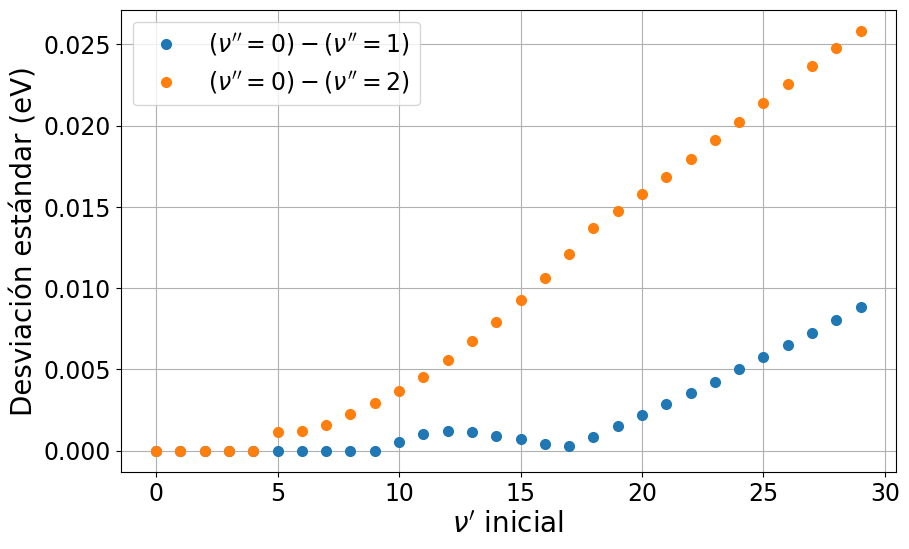

In [ ]:
# La transición $n = 0, \nu^\prime = 0 \rightarrow n=1, \nu^{\prime \prime} = 24$ corresponde al pico con indice 32 (548.33 nm)
# Tengo 6 picos de menor energía que el 32 en la serie 0, así que arranco desde nu = 18

nu_serie0 = np.arange(18, 18+len(serie0), dtype=int)
E_serie0_unc = []
for x in serie0_unc:
  E_serie0_unc.append((h*c)/((10**(-9))*x))
E_serie0_unc.reverse()

E_serie1_unc = []
for x in serie1_unc:
  E_serie1_unc.append((h*c)/((10**(-9))*x))
E_serie1_unc.reverse()

E_serie2_unc = []
for x in serie2_unc:
  E_serie2_unc.append((h*c)/((10**(-9))*x))
E_serie2_unc.reverse()

E_serie0 = unp.nominal_values(E_serie0_unc)
E_serie1 = unp.nominal_values(E_serie1_unc)
E_serie2 = unp.nominal_values(E_serie2_unc)
errE0 = unp.std_devs(E_serie0_unc)
errE1 = unp.std_devs(E_serie1_unc)
errE2 = unp.std_devs(E_serie2_unc)

def nu_serie(n_ini, serie): #si hay solapamiento de las series 0 y 1, n_ini es al menos 8
  return np.arange(n_ini, n_ini+len(serie), dtype=int)

def desv_est_dif(nu1, nu2, E1, E2):
  set1 = set(nu1)
  set2 = set(nu2)
  set_intersec = set1.intersection(set2)
  intersec = list(set_intersec)
  if len(intersec) == 0:
    return 0
  else:
    zip1 = zip(nu1, E1)
    zip2 = zip(nu2, E2)
    dict1 = dict(zip1)
    dict2 = dict(zip2)
    dif=[]
    for i in intersec:
      dif.append(dict1[i]-dict2[i])
    return np.std(dif)

plt.figure(figsize=(10, 6))
plt.errorbar(np.arange(0, 30), [desv_est_dif(nu_serie0, nu_serie(i, serie1), E_serie0, E_serie1) for i in np.arange(0, 30)], ms=7, fmt='o', label=r'$(\nu ^{\prime \prime}= 0) - (\nu ^{\prime \prime} = 1)$')
plt.errorbar(np.arange(0, 30), [desv_est_dif(nu_serie0, nu_serie(i, serie2), E_serie0, E_serie2) for i in np.arange(0, 30)], ms=7, fmt='o', label=r'$(\nu ^{\prime \prime}= 0) - (\nu ^{\prime \prime} = 2)$')
#plt.errorbar(np.arange(0, 30), [desv_est_dif(nu_serie(17, serie1), nu_serie(i, serie2), E_serie1, E_serie2) for i in np.arange(0, 30)], fmt='o', label=r'$(\nu ^\prime = 1) - (\nu ^\prime = 2)$')
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlabel(r'$\nu ^\prime$ inicial',size=20)
plt.ylabel('Desviación estándar (eV)', size=20)
plt.legend(fontsize=17)
plt.grid()
plt.savefig('desviacion_estandar.pdf', dpi=300)
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-1989769983.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta E$ (eV)')


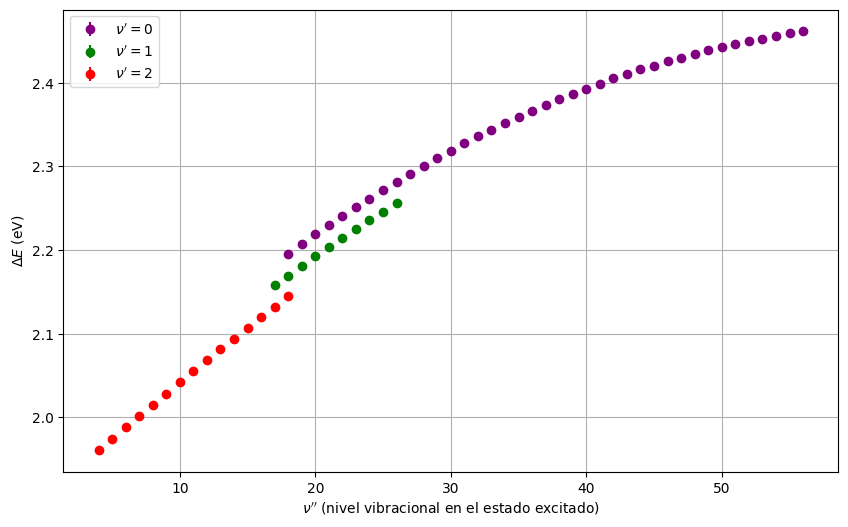

In [ ]:
nu_serie1 = nu_serie(17, serie1)
nu_serie2 = nu_serie(4, serie2)

plt.figure(figsize=(10, 6))
plt.errorbar(nu_serie0, E_serie0, yerr=errE0, fmt='o', color='purple', label =r'$\nu^\prime=0$')
plt.errorbar(nu_serie1, E_serie1, yerr=errE1, fmt='go', label =r'$\nu^\prime=1$')
plt.errorbar(nu_serie2, E_serie2, yerr=errE2, fmt='ro', label =r'$\nu^\prime=2$')
plt.xlabel(r'$\nu ^{\prime \prime}$ (nivel vibracional en el estado excitado)')
plt.ylabel('$\Delta E$ (eV)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
series_nu = (nu_serie0, nu_serie1, nu_serie2)
series_E = (E_serie0, E_serie1, E_serie2)
err_series_E = (errE0, errE1, errE2)

w_fund = (4.07+/-0.15)e+13
chi*w_fund = (1+/-5)e+11
w_ex = (2.443+/-0.007)e+13
chi*w_ex = (1.847+/-0.009)e+11
E_elec = 1.9541+/-0.0011
---------------------------------
De_fund = 3+/-15
De_ex = 0.532+/-0.004
alfa_fund = (0.8+/-2.1)e+10
alfa_ex = (1.0838+/-0.0026)e+10


<>:63: SyntaxWarning: invalid escape sequence '\D'
<>:63: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-1938707936.py:63: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta E$ (eV)', size=20)


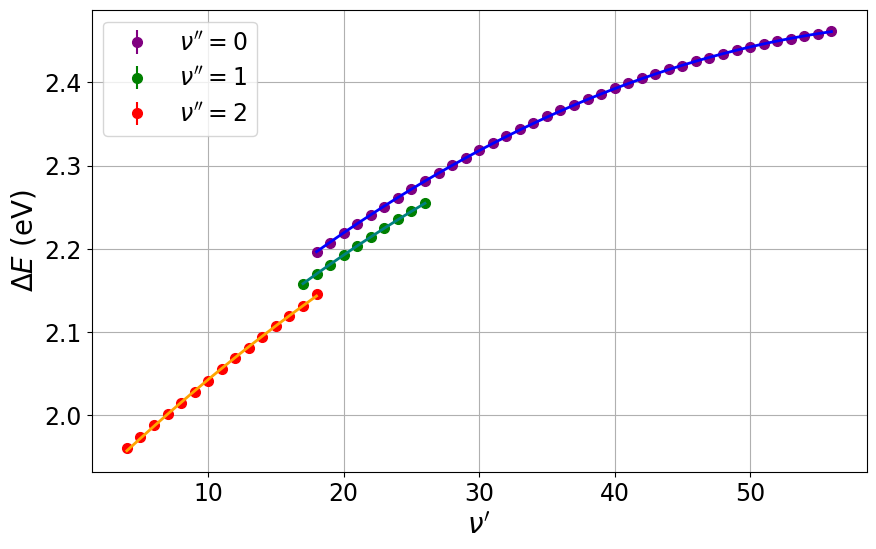

In [ ]:
# Ajuste simultáneo

nu = np.concatenate(series_nu)
E = np.concatenate(series_E)
err_E = np.concatenate(err_series_E)

def a(params, n): # b = omega, c = chi*omega
  E_elec, b, c = params
  return E_elec - hbar*(b*(n + 1/2)- c*((n + 1/2)**2))

def deltaE(params, n_fund, n_ex):
  b_fund, c_fund, b_ex, c_ex, E_elec = params
  return a((E_elec, b_fund, c_fund), n_fund) + hbar*(b_ex*(n_ex + 1/2)- c_ex*((n_ex + 1/2)**2))

def Ajuste(beta0):
  def func(params, n_ex):
    b_fund, c_fund, b_ex, c_ex, E_elec = params
    nu0 = n_ex[:len(nu_serie0)]
    nu1 = n_ex[len(nu_serie0):(len(nu_serie0)+len(nu_serie1))]
    nu2 = n_ex[(len(nu_serie0)+len(nu_serie1)):]
    return np.concatenate((deltaE(params, 0, nu0), deltaE(params, 1, nu1), deltaE(params, 2, nu2)))

  data = RealData(nu, E, sy=err_E)
  model = Model(func)
  odr = ODR(data, model, beta0=beta0, maxit=100000)
  out = odr.run()
  #out.pprint()
  return out.beta, out.sd_beta

params_unc = unp.uarray(Ajuste([4e13,1.3e11,2.4e13,1.5e11,2])[0], Ajuste([4e13,1.3e11,2.4e13,1.5e11,2])[1])
params = unp.nominal_values(params_unc)
tmp_params = params

txt=('w_fund', 'chi*w_fund', 'w_ex', 'chi*w_ex', 'E_elec')
for i in range(len(params_unc)):
  print(txt[i], '=', params_unc[i])

m_iodo = 1.315*10**(-6) #eV/c^2
mu = m_iodo/2

De_fund = h*params_unc[0]**2/(8*np.pi*params_unc[1])
De_ex = h*params_unc[2]**2/(8*np.pi*params_unc[3])
alfa_fund = unp.sqrt(4*mu*params_unc[1]/h)
alfa_ex = unp.sqrt(4*mu*params_unc[3]/h)

params_morse = (De_fund, De_ex, alfa_fund, alfa_ex)
txt_morse = ('De_fund', 'De_ex', 'alfa_fund', 'alfa_ex')

print('---------------------------------')
for i in range(len(params_morse)):
  print(txt_morse[i], '=', params_morse[i])

plt.figure(figsize=(10, 6))
plt.errorbar(nu_serie0, E_serie0, yerr=errE0, ms=7, fmt='o', color='purple', label =r'$\nu^{\prime \prime}=0$')
plt.errorbar(nu_serie1, E_serie1, yerr=errE1, ms=7, fmt='go', label =r'$\nu^{\prime \prime}=1$')
plt.errorbar(nu_serie2, E_serie2, yerr=errE2, ms=7, fmt='ro', label =r'$\nu^{\prime \prime}=2$')
plt.errorbar(nu_serie0, deltaE(params, 0, nu_serie0), linewidth=2, fmt='-', color='blue')
plt.errorbar(nu_serie1, deltaE(params, 1, nu_serie1), linewidth=2, fmt='-', color='teal')
plt.errorbar(nu_serie2, deltaE(params, 2, nu_serie2), linewidth=2, fmt='-', color='orange')
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlabel(r'$\nu ^{\prime}$', size=20)
plt.ylabel('$\Delta E$ (eV)', size=20)
plt.legend(fontsize=17)
plt.grid()
#plt.savefig('ajuste_series.pdf', dpi=300)
plt.show()

<>:62: SyntaxWarning: invalid escape sequence '\D'
<>:62: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-4016116460.py:62: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta E$ (eV)', size=20)


w_fund = (4.07138105496029+/-0)e+13
chi*w_fund = (1.0+/-0.6)e+11
w_ex = (2.4429494947846537+/-0)e+13
chi*w_ex = 184726550003.80026+/-0
E_elec = 1.9541349245221524+/-0
---------------------------------
De_fund = 2.9+/-1.9
De_ex = 0.5316677628727939+/-0
alfa_fund = (7.8+/-2.5)e+09
alfa_ex = 10838077915.784056+/-0


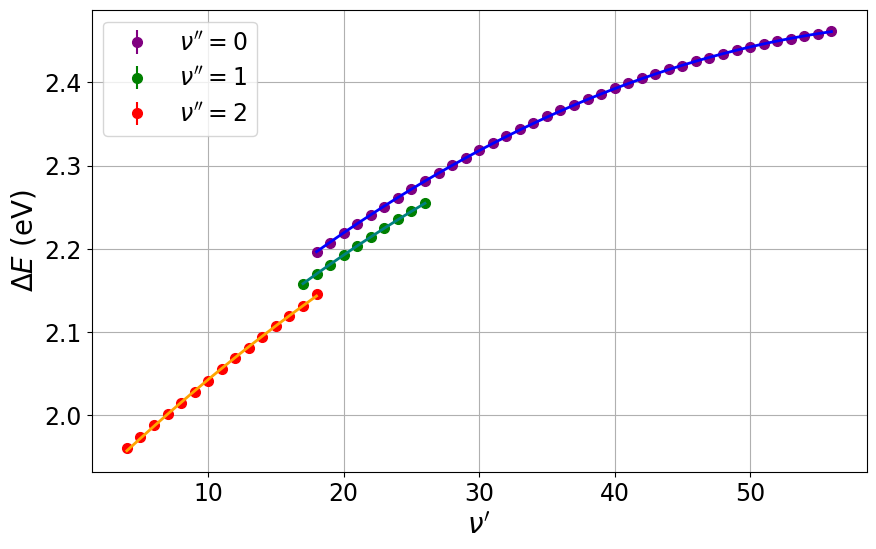

In [ ]:
# Ajuste simultáneo con todos los parámetros menos chi omega fund fijos

nu = np.concatenate(series_nu)
E = np.concatenate(series_E)
err_E = np.concatenate(err_series_E)

def a(params, n): # b = omega, c = chi*omega
  E_elec, b, c = params
  return E_elec - hbar*(b*(n + 1/2)- c*((n + 1/2)**2))

def deltaE(params, n_fund, n_ex):
  b_fund, c_fund, b_ex, c_ex, E_elec = params
  return a((E_elec, b_fund, c_fund), n_fund) + hbar*(b_ex*(n_ex + 1/2)- c_ex*((n_ex + 1/2)**2))

def Ajuste(beta0):
  def func(params, n_ex):
    b_fund, c_fund, b_ex, c_ex, E_elec = params
    nu0 = n_ex[:len(nu_serie0)]
    nu1 = n_ex[len(nu_serie0):(len(nu_serie0)+len(nu_serie1))]
    nu2 = n_ex[(len(nu_serie0)+len(nu_serie1)):]
    return np.concatenate((deltaE(params, 0, nu0), deltaE(params, 1, nu1), deltaE(params, 2, nu2)))

  data = RealData(nu, E, sy=err_E)
  model = Model(func)
  odr = ODR(data, model, beta0=beta0, ifixb=(0,1,0,0,0), maxit=100000)
  out = odr.run()
  #out.pprint()
  return out.beta, out.sd_beta

params_unc = unp.uarray(Ajuste(tmp_params)[0], Ajuste(tmp_params)[1])
params = unp.nominal_values(params_unc)

txt=('w_fund', 'chi*w_fund', 'w_ex', 'chi*w_ex', 'E_elec')
for i in range(len(params_unc)):
  print(txt[i], '=', params_unc[i])

m_iodo = 1.315*10**(-6) #eV/c^2
mu = m_iodo/2

De_fund = h*params_unc[0]**2/(8*np.pi*params_unc[1])
De_ex = h*params_unc[2]**2/(8*np.pi*params_unc[3])
alfa_fund = unp.sqrt(4*mu*params_unc[1]/h)
alfa_ex = unp.sqrt(4*mu*params_unc[3]/h)

params_morse = (De_fund, De_ex, alfa_fund, alfa_ex)
txt_morse = ('De_fund', 'De_ex', 'alfa_fund', 'alfa_ex')

print('---------------------------------')
for i in range(len(params_morse)):
  print(txt_morse[i], '=', params_morse[i])

plt.figure(figsize=(10, 6))
plt.errorbar(nu_serie0, E_serie0, yerr=errE0, ms=7, fmt='o', color='purple', label =r'$\nu^{\prime \prime}=0$')
plt.errorbar(nu_serie1, E_serie1, yerr=errE1, ms=7, fmt='go', label =r'$\nu^{\prime \prime}=1$')
plt.errorbar(nu_serie2, E_serie2, yerr=errE2, ms=7, fmt='ro', label =r'$\nu^{\prime \prime}=2$')
plt.errorbar(nu_serie0, deltaE(params, 0, nu_serie0), linewidth=2, fmt='-', color='blue')
plt.errorbar(nu_serie1, deltaE(params, 1, nu_serie1), linewidth=2, fmt='-', color='teal')
plt.errorbar(nu_serie2, deltaE(params, 2, nu_serie2), linewidth=2, fmt='-', color='orange')
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlabel(r'$\nu ^{\prime}$', size=20)
plt.ylabel('$\Delta E$ (eV)', size=20)
plt.legend(fontsize=17)
plt.grid()
#plt.savefig('ajuste_series.pdf', dpi=300)
plt.show()

<>:68: SyntaxWarning: invalid escape sequence '\D'
<>:68: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-651313050.py:68: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta E$ (eV)')


$\nu \prime$ = 0
----------------------------
a = 1.9402+/-0.0012
b = (2.447+/-0.009)e+13
c = (1.852+/-0.010)e+11
----------------------------
$\nu \prime$ = 1
----------------------------
a = 1.9170+/-0.0024
b = (2.376+/-0.033)e+13
c = (1.64+/-0.07)e+11
----------------------------
$\nu \prime$ = 2
----------------------------
a = 1.8977+/-0.0006
b = (2.158+/-0.018)e+13
c = (6.9+/-0.8)e+10
delta E elec = 1.953+/-0.004
Omega fund = (4.1+/-1.1)e+13
Chi*Omega fund = (3+/-4)e+12
Omega ex = 23267556771266.92
Chi*Omega ex = 139422056083.75058


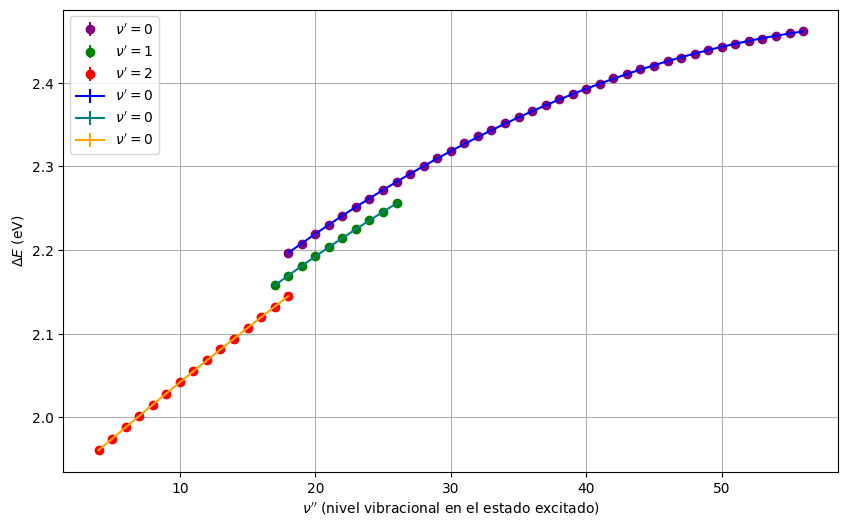

In [ ]:
# ajuste con 3 parámetros

def deltaE3(params, n):
  a , b, c = params # a = a, b = omega excitado, c = chi*omega excitado
  return a + hbar*(b*(n + 1/2)- c*((n + 1/2)**2))

def Ajuste(n_fund, beta0):
  data = RealData(series_nu[n_fund], series_E[n_fund], sy=err_series_E[n_fund])
  model = Model(deltaE3)
  odr = ODR(data, model, beta0=beta0, maxit=10000)
  out = odr.run()
  return out.beta, out.sd_beta

params0_unc = unp.uarray(Ajuste(0, [2, 2.4e13, 1.5e11])[0], Ajuste(0, [2, 2.4e13, 1.5e11])[1])
params1_unc = unp.uarray(Ajuste(1, [2, 2.4e13, 1.5e11])[0], Ajuste(1, [2, 2.4e13, 1.5e11])[1])
params2_unc = unp.uarray(Ajuste(2, [2, 2.4e13, 1.5e11])[0], Ajuste(2, [2, 2.4e13, 1.5e11])[1])

params0 = unp.nominal_values(params0_unc)
params1 = unp.nominal_values(params1_unc)
params2 = unp.nominal_values(params2_unc)

txt=('a', 'b', 'c')

print(r'$\nu \prime$ = 0')
print('----------------------------')
for i in range(len(params0)):
  print(txt[i], '=', params0_unc[i])
print('----------------------------')
print(r'$\nu \prime$ = 1')
print('----------------------------')
for i in range(len(params1)):
  print(txt[i], '=', params1_unc[i])
print('----------------------------')
print(r'$\nu \prime$ = 2')
print('----------------------------')
for i in range(len(params2)):
  print(txt[i], '=', params2_unc[i])

a_list = (params0_unc[0], params1_unc[0], params2_unc[0])
mat = ((15/8,-5/4,3/8), (2/hbar,-3/hbar,1/hbar), (1/(2*hbar),-1/hbar,1/(2*hbar)))

nuevo_txt = ('delta E elec', 'Omega fund', 'Chi*Omega fund', 'Omega ex', 'Chi*Omega ex')
nuevos_params = []

nuevos_params = np.dot(mat, a_list)

# for i in range(len(a_list)):
#   x=0
#   for j in range(len(a_list)):
#     x = x + mat[i][j]*a_list[j]
#   nuevos_params.append(x)
nuevos_params = nuevos_params.tolist()
nuevos_params.append(np.mean((params0[1], params1[1], params2[1])))
nuevos_params.append(np.mean((params0[2], params1[2], params2[2])))

print('=====================================')
for j in range(len(nuevos_params)):
  print(nuevo_txt[j], '=', nuevos_params[j])

plt.figure(figsize=(10, 6))
plt.errorbar(nu_serie0, E_serie0, yerr=errE0, fmt='o', color='purple', label =r'$\nu^\prime=0$')
plt.errorbar(nu_serie1, E_serie1, yerr=errE1, fmt='go', label =r'$\nu^\prime=1$')
plt.errorbar(nu_serie2, E_serie2, yerr=errE2, fmt='ro', label =r'$\nu^\prime=2$')
plt.errorbar(nu_serie0, deltaE3(params0, nu_serie0), yerr=errE0, fmt='-', color='blue', label =r'$\nu^\prime=0$')
plt.errorbar(nu_serie1, deltaE3(params1, nu_serie1), yerr=errE1, fmt='-', color='teal', label =r'$\nu^\prime=0$')
plt.errorbar(nu_serie2, deltaE3(params2, nu_serie2), yerr=errE2, fmt='-', color='orange', label =r'$\nu^\prime=0$')
plt.xlabel(r'$\nu ^{\prime \prime}$ (nivel vibracional en el estado excitado)')
plt.ylabel('$\Delta E$ (eV)')
plt.legend()
plt.grid()
plt.show()

<>:56: SyntaxWarning: invalid escape sequence '\D'
<>:56: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-169582618.py:56: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta E$ (eV)')


$\nu \prime$ = 0
----------------------------
w_fund = (5.90269460+/-0.00000035)e+19
chi*w_fund = (1.8+/-0)e+17
w_ex = (2.447+/-0.009)e+13
chi*w_ex = (1.852+/-0.010)e+11
E_elec = 19400.0+/-0
----------------------------
$\nu \prime$ = 1
----------------------------
w_fund = (-5.24013238+/-0.00000024)e+19
chi*w_fund = (-3.491297134848595+/-0)e+19
w_ex = (2.376+/-0.033)e+13
chi*w_ex = (1.64+/-0.07)e+11
E_elec = -29.548156672323262+/-0
----------------------------
$\nu \prime$ = 2
----------------------------
w_fund = (-0+/-7)e+19
chi*w_fund = (-0.0+/-2.8)e+19
w_ex = (2.158+/-0.019)e+13
chi*w_ex = (6.9+/-0.8)e+10
E_elec = 0.13890288325878153+/-0


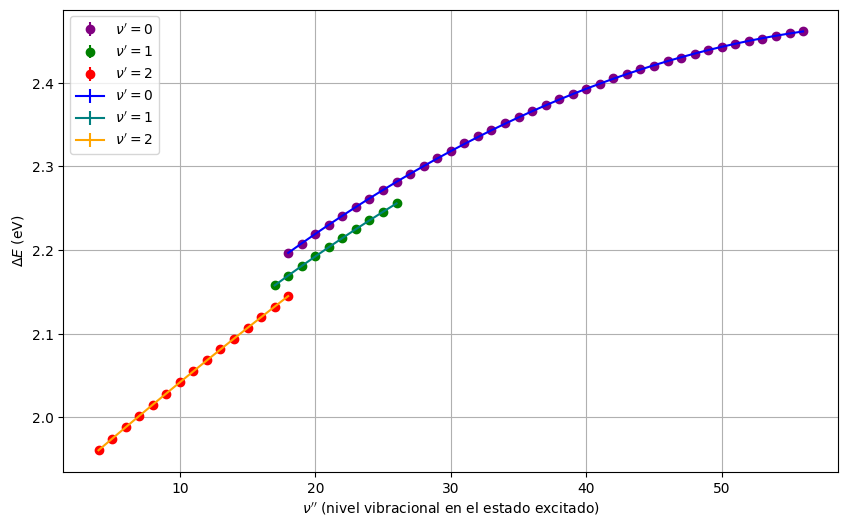

In [ ]:
# Ajuste con 5 parámetros

def a(params, n): # b = omega, c = chi*omega
  E_elec, b, c = params
  return E_elec - hbar*(b*(n + 1/2)- c*((n + 1/2)**2))

def deltaE(params, n_fund, n_ex):
  b_fund, c_fund, b_ex, c_ex, E_elec = params
  return a((E_elec, b_fund, c_fund), n_fund) + hbar*(b_ex*(n_ex + 1/2)- c_ex*((n_ex + 1/2)**2))

def Ajuste(n_fund, beta0):
  def func(params, n_ex):
    b_fund, c_fund, b_ex, c_ex, E_elec = params
    return deltaE(params, n_fund, n_ex)

  data = RealData(series_nu[n_fund], series_E[n_fund], sy=err_series_E[n_fund])
  model = Model(func)
  odr = ODR(data, model, beta0=beta0)
  out = odr.run()
  #out.pprint()
  return out.beta, out.sd_beta

params0_unc = unp.uarray(Ajuste(0, [6.4e19, 1.8e17, 3.84e13, 2.5e11, 1.94e4])[0], Ajuste(0, [6.4e19, 1.8e17, 3.84e13, 2.5e11, 1.94e4])[1])
params1_unc = unp.uarray(Ajuste(1, [6.4e19, 1.8e17, 3.84e19, 2.5e17, 1.94])[0], Ajuste(1, [6.4e19, 1.8e17, 3.84e19, 2.5e17, 1.94])[1])
params2_unc = unp.uarray(Ajuste(2, [6.4e19, 1.8e17, 3.84e19, 2.5e17, 1.94])[0], Ajuste(2, [6.4e19, 1.8e17, 3.84e19, 2.5e17, 1.94])[1])

params0 = unp.nominal_values(params0_unc)
params1 = unp.nominal_values(params1_unc)
params2 = unp.nominal_values(params2_unc)

txt=('w_fund', 'chi*w_fund', 'w_ex', 'chi*w_ex', 'E_elec')

print(r'$\nu \prime$ = 0')
print('----------------------------')
for i in range(len(params0)):
  print(txt[i], '=', params0_unc[i])
print('----------------------------')
print(r'$\nu \prime$ = 1')
print('----------------------------')
for i in range(len(params1)):
  print(txt[i], '=', params1_unc[i])
print('----------------------------')
print(r'$\nu \prime$ = 2')
print('----------------------------')
for i in range(len(params2)):
  print(txt[i], '=', params2_unc[i])

plt.figure(figsize=(10, 6))
plt.errorbar(nu_serie0, E_serie0, yerr=errE0, fmt='o', color='purple', label =r'$\nu^\prime=0$')
plt.errorbar(nu_serie1, E_serie1, yerr=errE1, fmt='go', label =r'$\nu^\prime=1$')
plt.errorbar(nu_serie2, E_serie2, yerr=errE2, fmt='ro', label =r'$\nu^\prime=2$')
plt.errorbar(nu_serie0, deltaE(params0, 0, nu_serie0), yerr=errE0, fmt='-', color='blue', label =r'$\nu^\prime=0$')
plt.errorbar(nu_serie1, deltaE(params1, 1, nu_serie1), yerr=errE1, fmt='-', color='teal', label =r'$\nu^\prime=1$')
plt.errorbar(nu_serie2, deltaE(params2, 2, nu_serie2), yerr=errE2, fmt='-', color='orange', label =r'$\nu^\prime=2$')
plt.xlabel(r'$\nu ^{\prime \prime}$ (nivel vibracional en el estado excitado)')
plt.ylabel('$\Delta E$ (eV)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from scipy.optimize import curve_fit
def func(x,a,b,c):
  return a+hbar*(b*(x+1/2)-c*(x+1/2)**2)
popt, pcov = curve_fit(func, series_nu[2], series_E[2], p0=(1.9,2.3*10**13,1.8*10**11))
print(popt)
print(pcov)

[1.89771576e+00 2.15753393e+13 6.91683427e+10]
[[ 3.85118683e-07 -1.07607211e+08 -4.39361755e+06]
 [-1.07607211e+08  3.19516072e+22  1.35155731e+21]
 [-4.39361755e+06  1.35155731e+21  5.87633373e+19]]
